In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

sns.set_style("whitegrid", rc={"grid.color": ".9", "axes.edgecolor": ".9",})

In [2]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'
data = 'data_simu'
save_dir = f'../figures/{data}'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [ ]:
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'velovi', 'topovelo', 'stt', 'velovgi']
spatial_types = ['bidirect', 'radial']
noise_types = ['exp', 'pos']
metric_file_names = ['_coord_redo', '_coord', '', '', '', '_coord_redo', '_coord_redo', '']
# velocity acc不包含stt(vj)
velocity_acc_idx_dict = {model: '_velovgi_velocity' if model == 'velovgi' else '' for model in models}
time_idx_dict = {
    'scvelo': '_pred_t_norm',
    'scvelo(avg)': '_fit_t_mean',
    'unitvelo': '_pred_t_norm',
    'velovae': '',
    'deepvelo_cui': '',
    'velovi': '',
    'topovelo': '_pred_t_norm',
    'velovgi': '_fit_t',
}
spatial_velo_consist_idx_dict = {
    'scvelo': '',
    'unitvelo': '_unitvelo_velocity',
    'velovae': '',
    'deepvelo_cui': '',
    'velovi': '',
    'topovelo': '',
    'stt': '_stt_velocity',
    'stt(vj)': '_vj',
    'velovgi': '_velovgi_velocity',
}
results_all = {}
for metric_name in ['velocity_acc', 'time_corr_spearman', 'spatial_velo_consist', 'spatial_time_consist']:
    results = {}
    for spatial_type in spatial_types:
        results[spatial_type] = {}
        for noise_type in noise_types:
            results[spatial_type][noise_type] = {}
            if metric_name == 'velocity_acc':
                for i, model in enumerate(models):
                    metrics = []
                    if noise_type == 'exp':
                        noise_levels = ['0.1', '0.5', '1', '5', '10']
                    else:
                        noise_levels = ['0', '0.5', '1']
                    for noise_level in noise_levels:
                        path = f'{base_dir}/{data}/{model}/{spatial_type}/{noise_type}_noise/{noise_level}'
                        for timestamp in os.listdir(path):
                            ts_path = os.path.join(path, timestamp)
                            file = f'metric{metric_file_names[i]}.csv'
                            metric_path = os.path.join(ts_path, file)
                            if not os.path.exists(metric_path):
                                file = f'metric{metric_file_names[i].removesuffix("_redo")}.csv'
                                metric_path = os.path.join(ts_path, file)
                            if not os.path.exists(metric_path):
                                print(f"File not found: {metric_path}")
                                continue
                            df_metric = pd.read_csv(metric_path, index_col=0)
                            value = float(df_metric.loc[f'{metric_name}{velocity_acc_idx_dict[model]}', '0'])
                            row = {
                                'noise_level': float(noise_level),
                                'timestamp': timestamp,
                                metric_name: value
                            }
                            metrics.append(row)
                    df = pd.DataFrame(metrics)
                    results[spatial_type][noise_type][model] = df
            elif metric_name == 'spatial_velo_consist':
                for i, model in enumerate(models):
                    metrics = []
                    if model == 'stt':
                        metrics_vj = []
                    if noise_type == 'exp':
                        noise_levels = ['0.1', '0.5', '1', '5', '10']
                    else:
                        noise_levels = ['0', '0.5', '1']
                    for noise_level in noise_levels:
                        path = f'{base_dir}/{data}/{model}/{spatial_type}/{noise_type}_noise/{noise_level}'
                        for timestamp in os.listdir(path):
                            ts_path = os.path.join(path, timestamp)
                            file = f'metric{metric_file_names[i]}.csv'
                            metric_path = os.path.join(ts_path, file)
                            if not os.path.exists(metric_path):
                                file = f'metric{metric_file_names[i].removesuffix("_redo")}.csv'
                                metric_path = os.path.join(ts_path, file)
                            if not os.path.exists(metric_path):
                                print(f"File not found: {metric_path}")
                                continue
                            df_metric = pd.read_csv(metric_path, index_col=0)
                            value = float(df_metric.loc[f'{metric_name}{spatial_velo_consist_idx_dict[model]}', '0'])
                            row = {
                                'noise_level': float(noise_level),
                                'timestamp': timestamp,
                                metric_name: value
                            }
                            metrics.append(row)
                            if model == 'stt':
                                value_vj = float(df_metric.loc[f'{metric_name}{spatial_velo_consist_idx_dict["stt(vj)"]}', '0'])
                                row_vj = {
                                    'noise_level': float(noise_level),
                                    'timestamp': timestamp,
                                    metric_name: value_vj
                                }
                                metrics_vj.append(row_vj)
                    df = pd.DataFrame(metrics)
                    results[spatial_type][noise_type][model] = df
                    if model == 'stt':
                        df_vj = pd.DataFrame(metrics_vj)
                        results[spatial_type][noise_type]['stt(vj)'] = df_vj
            else: # metric_name in ['time_corr_spearman', 'spatial_time_consist']
                for i, model in enumerate(models):
                    if model == 'stt':
                        continue
                    metrics = []
                    if model == 'scvelo':
                        metrics_avg = []
                    if noise_type == 'exp':
                        noise_levels = ['0.1', '0.5', '1', '5', '10']
                    else:
                        noise_levels = ['0', '0.5', '1']
                    for noise_level in noise_levels:
                        path = f'{base_dir}/{data}/{model}/{spatial_type}/{noise_type}_noise/{noise_level}'
                        for timestamp in os.listdir(path):
                            ts_path = os.path.join(path, timestamp)
                            file = f'metric{metric_file_names[i]}.csv'
                            metric_path = os.path.join(ts_path, file)
                            if not os.path.exists(metric_path):
                                file = f'metric{metric_file_names[i].removesuffix("_redo")}.csv'
                                metric_path = os.path.join(ts_path, file)
                            if not os.path.exists(metric_path):
                                print(f"File not found: {metric_path}")
                                continue
                            df_metric = pd.read_csv(metric_path, index_col=0)
                            if metric_name == 'time_corr_spearman':
                                value = float(df_metric.loc[f'{metric_name}{time_idx_dict[model]}', '0'])
                            else:
                                value = float(df_metric.loc[f'{metric_name}{time_idx_dict[model]}', '0'])
                            row = {
                                'noise_level': float(noise_level),
                                'timestamp': timestamp,
                                metric_name: value
                            }
                            metrics.append(row)
                            if model == 'scvelo':
                                if metric_name == 'time_corr_spearman':
                                    value_avg = float(df_metric.loc[f'{metric_name}{time_idx_dict["scvelo(avg)"]}', '0'])
                                else:
                                    value_avg = float(df_metric.loc[f'{metric_name}{time_idx_dict["scvelo(avg)"]}', '0'])
                                row_avg = {
                                    'noise_level': float(noise_level),
                                    'timestamp': timestamp,
                                    metric_name: value_avg
                                }
                                metrics_avg.append(row_avg)
                    df = pd.DataFrame(metrics)
                    results[spatial_type][noise_type][model] = df
                    if model == 'scvelo':
                        df_avg = pd.DataFrame(metrics_avg)
                        results[spatial_type][noise_type]['scvelo(avg)'] = df_avg
    results_all[metric_name] = results
results_all

File not found: /home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs/data_simu/stt/bidirect/pos_noise/0.5/20240605_223033/metric_coord.csv
File not found: /home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs/data_simu/stt/bidirect/pos_noise/0.5/20240605_223023/metric_coord.csv
File not found: /home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs/data_simu/stt/bidirect/pos_noise/1/20240605_223449/metric_coord.csv
File not found: /home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs/data_simu/stt/radial/exp_noise/1/20240605_224007/metric_coord.csv
File not found: /home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs/data_simu/stt/radial/pos_noise/0/20240605_224415/metric_coord.csv
File not found: /home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs/data_simu/stt/radial/pos_noise/1/20240605_225508/metric_coord.csv
File not found: /home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs/data_simu/stt/radial/pos_noise/1/20240605_225513/metric_coord.

{'velocity_acc': {'bidirect': {'exp': {'scvelo':     noise_level        timestamp  velocity_acc
    0           0.1  20240605_222331      0.823569
    1           0.1  20240605_222333      0.816772
    2           0.1  20240605_222326      0.820103
    3           0.1  20240605_222338      0.824421
    4           0.1  20240605_222335      0.804229
    5           0.5  20240605_222515      0.809299
    6           0.5  20240605_222514      0.811197
    7           0.5  20240605_222517      0.809582
    8           0.5  20240605_222510      0.810368
    9           0.5  20240605_222520      0.813191
    10          1.0  20240605_233602      0.806144
    11          1.0  20240605_222708      0.818814
    12          1.0  20240605_222749      0.825342
    13          1.0  20240605_222706      0.823619
    14          1.0  20240605_222704      0.819584
    15          5.0  20240615_160727      0.876416
    16          5.0  20240615_160720      0.875578
    17          5.0  20240615_160712 

In [ ]:
results_sorted = {}
noise_type = 'exp'

for metric_name in ['velocity_acc', 'time_corr_spearman', 'spatial_velo_consist', 'spatial_time_consist']:
    results_sorted[metric_name] = {}
    for spatial_type in ['bidirect', 'radial']:
        results_sorted[metric_name][spatial_type] = {}
        for noise_type in ['exp', 'pos']:
            df_final = pd.DataFrame()
            for model in results_all[metric_name][spatial_type][noise_type].keys():
                df = results_all[metric_name][spatial_type][noise_type][model]
                df_result = df.groupby('noise_level')[metric_name].agg(['mean', 'std'])
                df_result['model'] = model if model != 'deepvelo_cui' else 'deepvelo(cui)'
                df_result.reset_index(inplace=True)
                df_result.set_index(['model', 'noise_level'], inplace=True)
                df_final = pd.concat([df_final, df_result], axis=0)
            results_sorted[metric_name][spatial_type][noise_type] = df_final
results_sorted


{'velocity_acc': {'bidirect': {'exp':                                mean       std
   model         noise_level                    
   scvelo        0.1          0.817819  0.008180
                 0.5          0.810727  0.001563
                 1.0          0.818701  0.007529
                 5.0          0.875771  0.000492
                 10.0         0.857997  0.001960
   unitvelo      0.1          0.700084  0.001762
                 0.5          0.703247  0.002055
                 1.0          0.706489  0.001734
                 5.0          0.703042  0.002635
                 10.0         0.139613  0.018342
   velovae       0.1          0.512178  0.093848
                 0.5          0.547179  0.035972
                 1.0          0.587599  0.017716
                 5.0          0.479791  0.053144
                 10.0        -0.205107  0.162649
   deepvelo(cui) 0.1          0.802220  0.016224
                 0.5          0.819653  0.017136
                 1.0          0.79

/tmp/ipykernel_1827883/3232555585.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_curr['noise_level'] = df_curr['noise_level'].astype('category')
/tmp/ipykernel_1827883/3232555585.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_curr['noise_level'] = df_curr['noise_level'].astype('category')
/tmp/ipykernel_1827883/3232555585.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

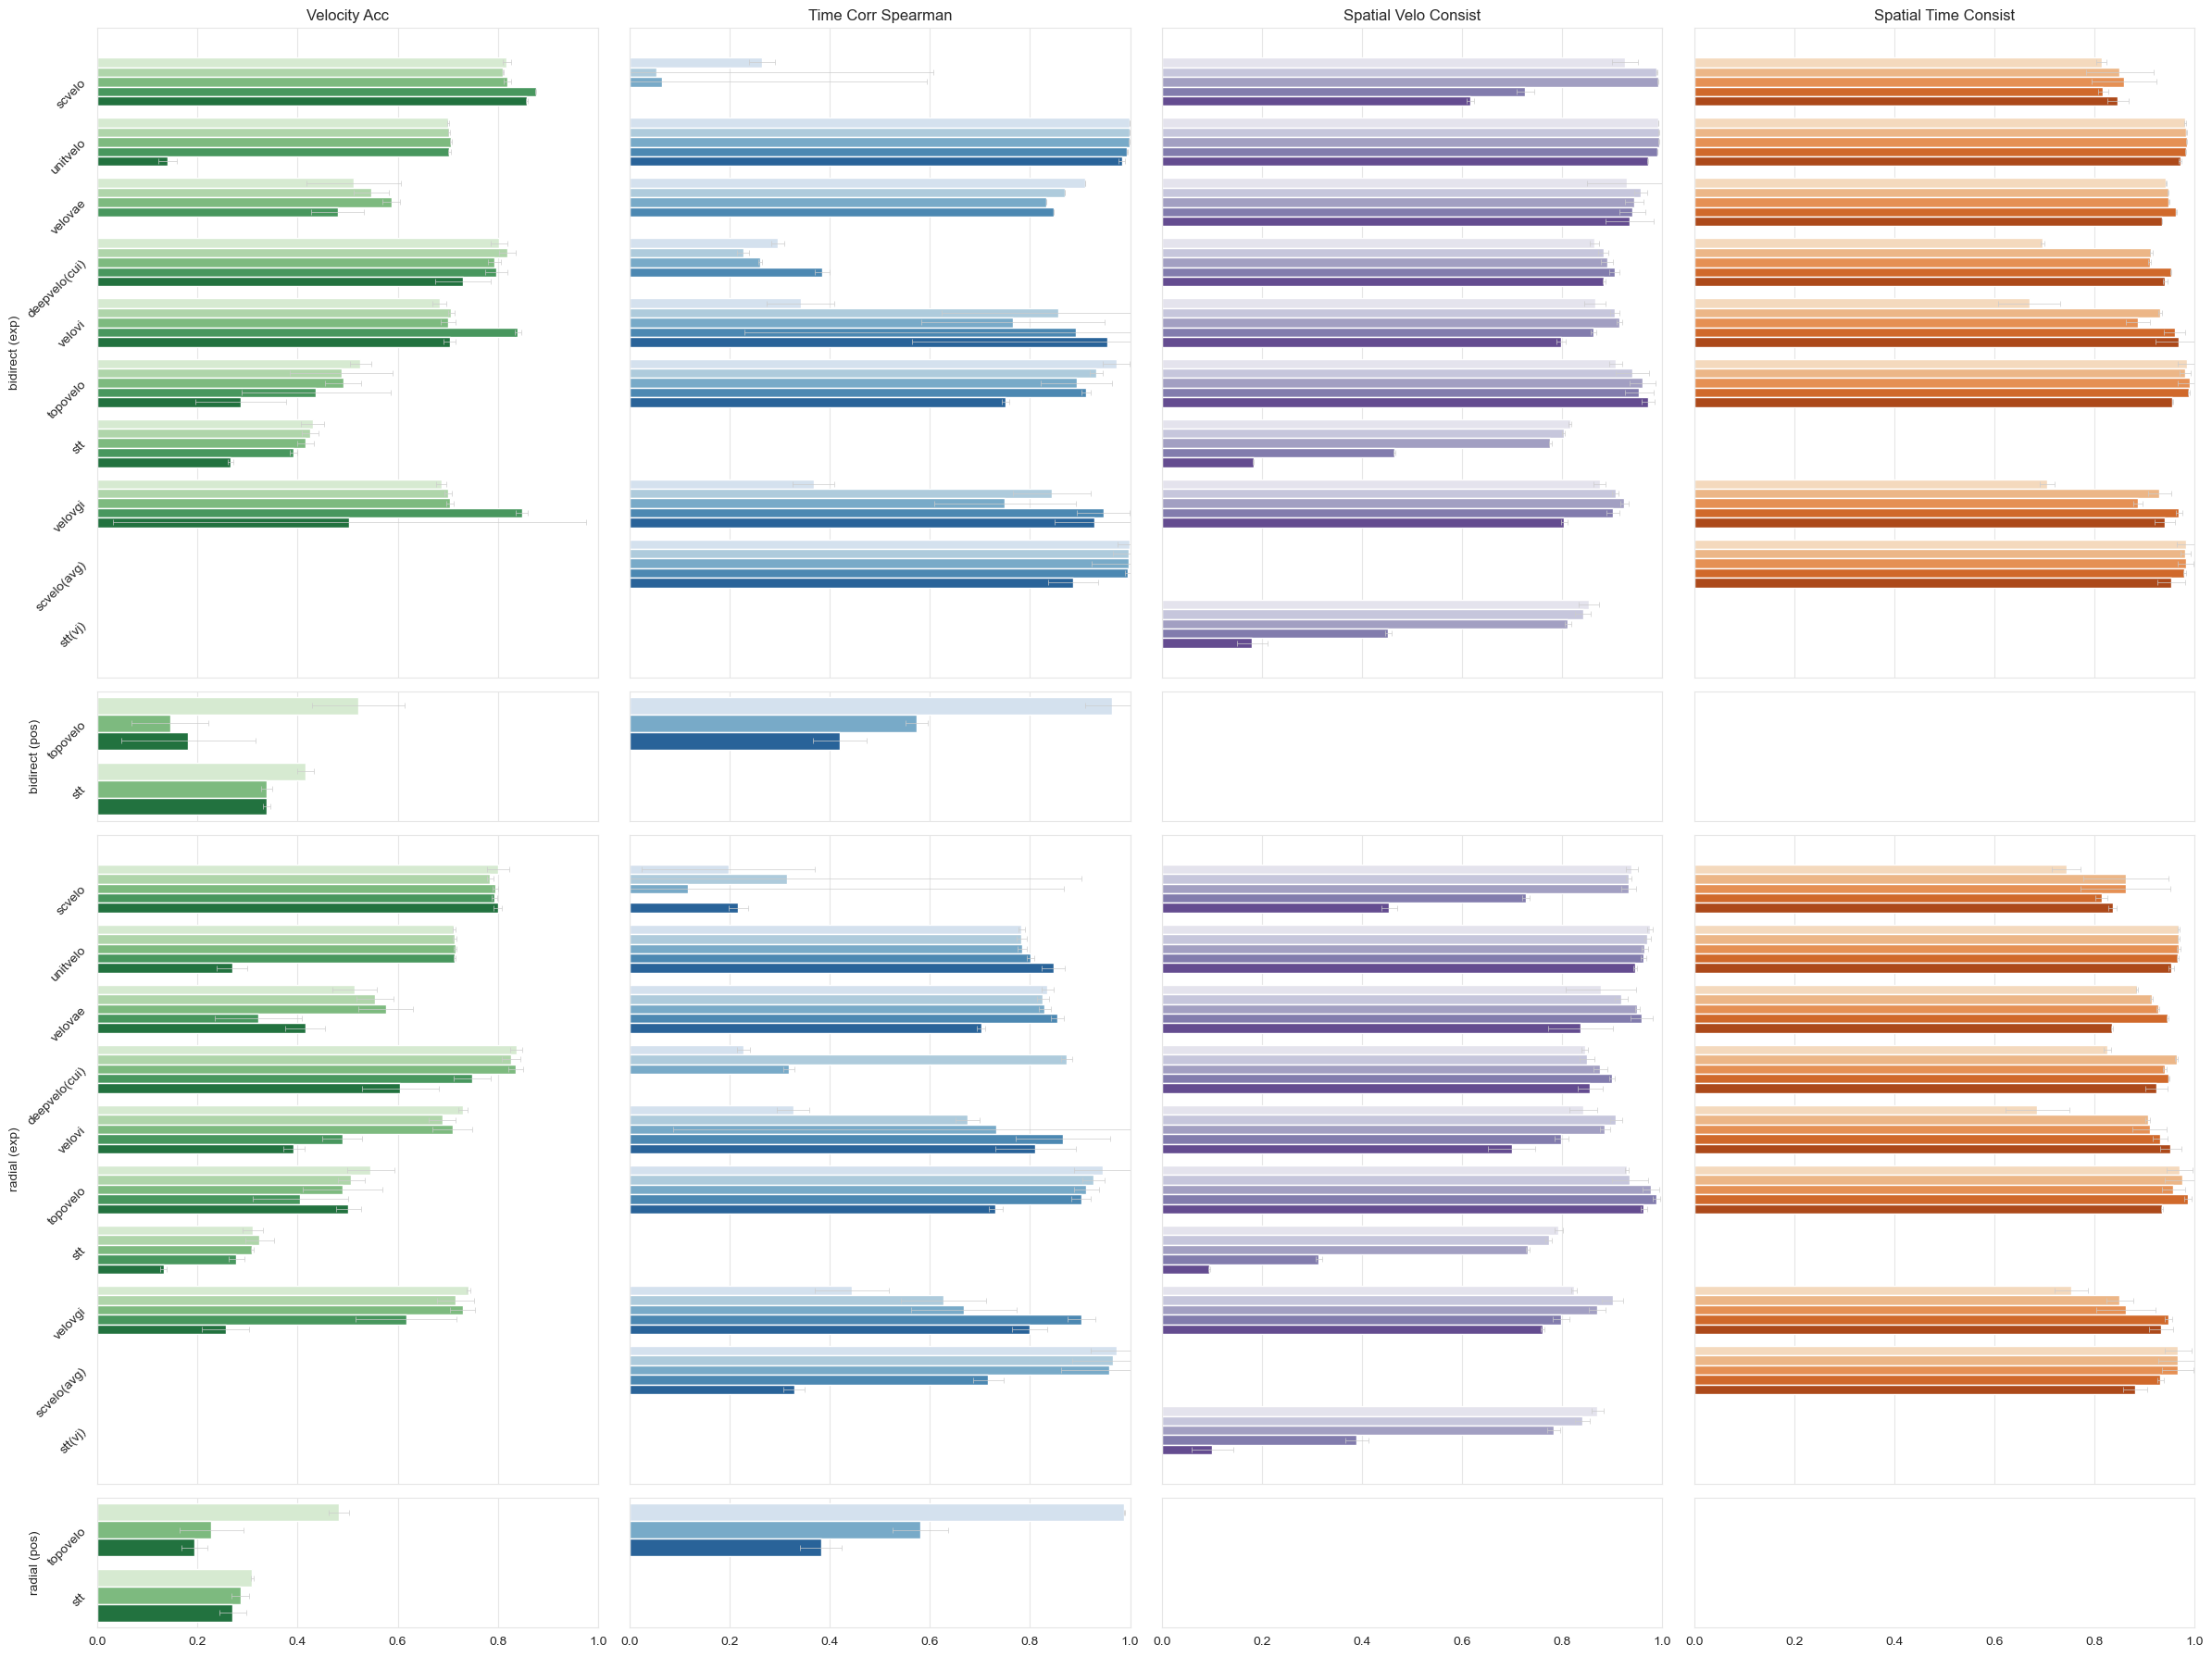

In [75]:
color_maps = [plt.cm.Greens, plt.cm.Blues, plt.cm.Purples, plt.cm.Oranges]
fig, axs = plt.subplots(4, 4, figsize=(24, 18), sharex='col', sharey='row', gridspec_kw={'height_ratios': [5, 1, 5, 1], 'width_ratios': [1, 1, 1, 1]})
for k, metric_name in enumerate(['velocity_acc', 'time_corr_spearman', 'spatial_velo_consist', 'spatial_time_consist']):
    for i, spatial_type in enumerate(['bidirect', 'radial']):
        for j, noise_type in enumerate(['exp', 'pos']):
            df_curr = results_sorted[metric_name][spatial_type][noise_type]
            df_curr.reset_index(inplace=True)
            if noise_type == 'pos':
                if metric_name in ['spatial_velo_consist', 'spatial_time_consist']:
                    axs[i * 2 + j][k].grid(False)
                    continue
                df_curr = df_curr[df_curr['model'].isin(['topovelo', 'stt', 'stt(vj)'])]
            df_curr['noise_level'] = df_curr['noise_level'].astype('category')
            noise_levels = df_curr['noise_level'].unique()
            noise_colors = color_maps[k](np.linspace(0.2, 0.8, len(noise_levels)))
            noise_color_map = dict(zip(noise_levels, noise_colors))
            sns.barplot(data=df_curr, y='model', x='mean', hue='noise_level', palette=noise_color_map, orient='h', ax=axs[i * 2 + j][k])
            bars = axs[i * 2 + j][k].patches
            for ii in range(df_curr['model'].nunique()):
                for jj in range(df_curr['noise_level'].nunique()):
                    bar = bars[jj * df_curr['model'].nunique() + ii]
                    if bar.get_height() != 0:
                        error = df_curr['std'].iloc[ii * df_curr['noise_level'].nunique() + jj]
                        y = bar.get_y() + bar.get_height() / 2
                        x = bar.get_width()
                        axs[i * 2 + j][k].errorbar(
                            x=x, 
                            y=y, 
                            xerr=error, 
                            fmt='none', 
                            ecolor='.8', 
                            capsize=2,
                            capthick=0.5,
                            elinewidth=0.5
                        )
            legend = axs[i * 2 + j][k].get_legend().remove()
            axs[i * 2 + j][k].set_xlim(0, 1)
            axs[i * 2 + j][k].set_xlabel('')
            axs[i * 2 + j][k].set_ylabel(f'{spatial_type} ({noise_type})')
            if i == 0 and j == 0:
                axs[i * 2 + j][k].set_title(metric_name.replace('_', ' ').title())
            for label in axs[i * 2 + j][k].get_yticklabels():
                label.set_rotation(45)
                label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/metric_barplot.svg', bbox_inches='tight')
plt.show()